Accuracy: 0.8253846153846154

Confusion Matrix:
 [[338 113]
 [114 735]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75       451
           1       0.87      0.87      0.87       849

    accuracy                           0.83      1300
   macro avg       0.81      0.81      0.81      1300
weighted avg       0.83      0.83      0.83      1300



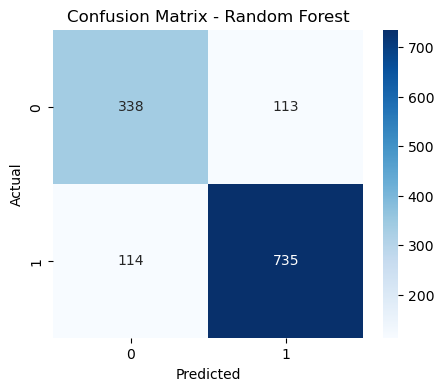

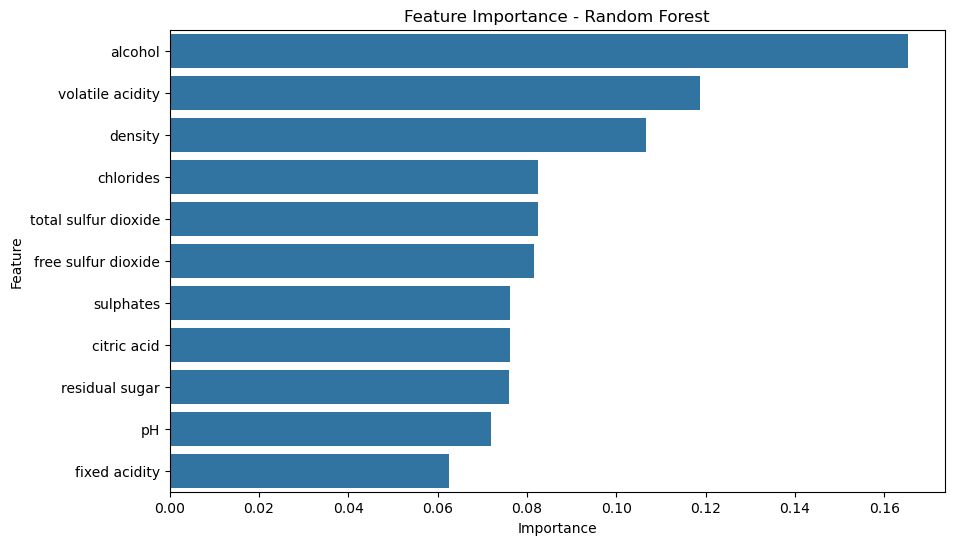

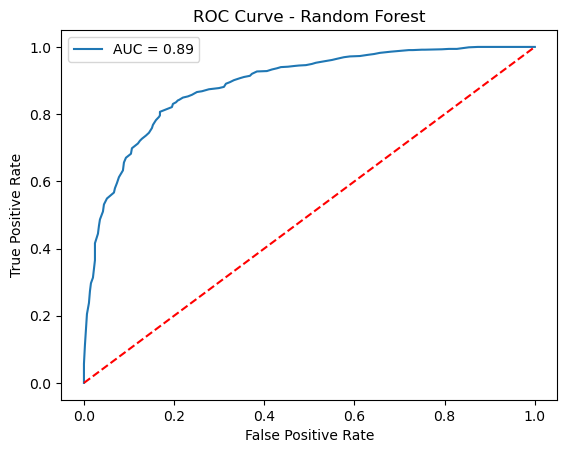


Cross Validation Scores: [0.44153846 0.65461538 0.71978445 0.74518861 0.75596613]
Average Accuracy: 0.6634186060283058

Model evaluation completed successfully.
Random Forest provides strong performance with feature interpretability.


In [2]:
# ===============================
# RANDOM FOREST (UPGRADED VERSION)
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# -------------------------------
# LOAD DATA
# -------------------------------
red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')
df = pd.concat([red, white])

# Convert to binary classification
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

# Features & target
X = df.drop('quality', axis=1)
y = df['quality']

# -------------------------------
# FEATURE SCALING
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# TRAIN TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -------------------------------
# MODEL TRAINING
# -------------------------------
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# PREDICTION
# -------------------------------
pred = model.predict(X_test)

# -------------------------------
# EVALUATION
# -------------------------------
acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))

# -------------------------------
# CONFUSION MATRIX VISUALIZATION
# -------------------------------
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------------
# FEATURE IMPORTANCE
# -------------------------------
importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance - Random Forest")
plt.show()

# -------------------------------
# ROC CURVE
# -------------------------------
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# -------------------------------
# CROSS VALIDATION
# -------------------------------
scores = cross_val_score(model, X_scaled, y, cv=5)

print("\nCross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

# -------------------------------
# SAVE RESULTS
# -------------------------------
pd.DataFrame({
    'Algorithm': ['Random Forest'],
    'Accuracy': [acc]
}).to_csv("random_forest.csv", index=False)

# -------------------------------
# CONCLUSION (PRINT)
# -------------------------------
print("\nModel evaluation completed successfully.")
print("Random Forest provides strong performance with feature interpretability.")